In order to try and give an overview of what is significant and unique for each party, we generate wordclouds that use TF-IDF to balance the frequency against the uniqueness of the words. The corpus are all resumes and titles of any case (sag) voted for in the period and the document for each party is each title and resume in which the majority of the party voters voted yes.

Read in the df that contains the votes for a case aggregated by party and the df containing the title, resume and topics for each voting session.

In [1]:
import pandas as pd
party_votes_df = pd.read_csv('voting-data/voting_session_party_percentages.csv')
voting_sessions_df = pd.read_csv('voting-data/voting_sessions_enriched.csv')

In [16]:
party_votes_df

,afstemning_id,party,Period,afstemning_vedtaget,total_potential_votes,total_cast_votes,votes_type_1,votes_type_2,votes_type_3,votes_type_4,agree_percentage_of_cast_votes,disagree_percentage_of_cast_votes,abstain_percentage_of_cast_votes,absent_percentage_of_potential_votes
0,1,Alternativet,68,True,1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000
1,1,Danmarksdemokraterne,68,True,8,6.0,6.0,0.0,2.0,0.0,1.0,0.0,0.0,0.250000
2,1,Dansk Folkeparti,68,True,12,7.0,7.0,0.0,5.0,0.0,1.0,0.0,0.0,0.416667
3,1,Det Konservative Folkeparti,68,True,8,5.0,5.0,0.0,3.0,0.0,1.0,0.0,0.0,0.375000
4,1,Enhedslisten,68,True,13,8.0,8.0,0.0,5.0,0.0,1.0,0.0,0.0,0.384615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168955,10382,Sambandsflokkurin,71,True,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000
168956,10382,Socialdemokratiet,71,True,50,31.0,31.0,0.0,19.0,0.0,1.0,0.0,0.0,0.380000
168957,10382,Socialistisk Folkeparti,71,True,15,10.0,10.0,0.0,5.0,0.0,1.0,0.0,0.0,0.333333
168958,10382,Uden for folketingsgrupperne,71,True,5,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,1.000000


In [ ]:
voting_sessions_df

In [7]:
import numpy as np
from collections import Counter
import re
text = "Dette er en prøve tekst med nogle ord. Nogle ord er hyppige, andre er sjældne. Flygtninge og integration er vigtige emner."

tokens = re.findall(r'[a-zæøå]+', text.lower())

print("Tokens:", tokens)

Tokens: ['dette', 'er', 'en', 'prøve', 'tekst', 'med', 'nogle', 'ord', 'nogle', 'ord', 'er', 'hyppige', 'andre', 'er', 'sjældne', 'flygtninge', 'og', 'integration', 'er', 'vigtige', 'emner']


No function yet.

In [34]:
voting_sessions_df.head()

,afstemning_id,afstemning_nummer,afstemning_konklusion,afstemning_vedtaget,afstemning_kommentar,afstemning_dato,afstemning_opdateringsdato,afstemning_typeid,møde_id,møde_dato,...,score_erhverv,score_finans_budget,score_arbejdsmarked_velfærd,score_immigration,score_forsvar_sikkerhed,score_udenrigs_eu,score_retspolitik,score_transport_infrastruktur,score_bolig,score_social_familie
0,1,411,"Vedtaget\n\n108 stemmer for forslaget (V, S, D...",True,NaN,NaN,2014-09-09T09:05:59.653,2,17,2014-09-09 09:00:00,...,0,0,0,0,0,0,0,0,0,0
1,2,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,NaN,2014-09-09T09:25:05.717,1,18,2014-09-09 09:15:00,...,2,2,0,0,1,1,0,0,0,0
2,3,1,"Vedtaget\n\n59 stemmer for forslaget (S, RV, S...",True,NaN,NaN,2018-01-24T16:46:33.99,3,41,2012-10-04 10:00:00,...,0,0,0,0,0,0,1,0,0,1
3,4,7,"Vedtaget\n\n72 stemmer for forslaget (S, DF, R...",True,NaN,NaN,2018-01-25T10:25:25.64,1,156,2012-11-06 00:00:00,...,0,1,2,0,0,0,0,0,0,0
4,5,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,NaN,2017-08-10T12:57:52.27,1,18,2014-09-09 09:15:00,...,2,2,0,0,1,1,0,0,0,0


In [72]:
voting_sessions_df['Period'].unique()

array([68, 67, 69, 66, 65, 70, 71])

In [ ]:
voting_sessions_df.columns

Index(['afstemning_id', 'afstemning_nummer', 'afstemning_konklusion',
       'afstemning_vedtaget', 'afstemning_kommentar', 'afstemning_dato',
       'afstemning_opdateringsdato', 'afstemning_typeid', 'møde_id',
       'møde_dato', 'møde_titel', 'møde_nummer', 'møde_periodeid',
       'sagstrin_id', 'sagstrin_titel', 'sagstrin_typeid', 'sag_id',
       'sag_titel', 'sag_titelkort', 'sag_resume', 'sag_nummer',
       'sag_nummerprefix', 'sag_opdateringsdato', 'sag_typeid',
       'sag_periodeid', 'sag_statusid', 'Period', 'topic_texts',
       'primary_topic', 'all_topics', 'topic_count', 'total_matches',
       'score_klima_miljø', 'score_sundhed', 'score_uddannelse', 'score_skat',
       'score_erhverv', 'score_finans_budget', 'score_arbejdsmarked_velfærd',
       'score_immigration', 'score_forsvar_sikkerhed', 'score_udenrigs_eu',
       'score_retspolitik', 'score_transport_infrastruktur', 'score_bolig',
       'score_social_familie'],
      dtype='object')

In [12]:
party_votes_df

,afstemning_id,party,Period,afstemning_vedtaget,total_potential_votes,total_cast_votes,votes_type_1,votes_type_2,votes_type_3,votes_type_4,agree_percentage_of_cast_votes,disagree_percentage_of_cast_votes,abstain_percentage_of_cast_votes,absent_percentage_of_potential_votes
0,1,Alternativet,68,True,1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000
1,1,Danmarksdemokraterne,68,True,8,6.0,6.0,0.0,2.0,0.0,1.0,0.0,0.0,0.250000
2,1,Dansk Folkeparti,68,True,12,7.0,7.0,0.0,5.0,0.0,1.0,0.0,0.0,0.416667
3,1,Det Konservative Folkeparti,68,True,8,5.0,5.0,0.0,3.0,0.0,1.0,0.0,0.0,0.375000
4,1,Enhedslisten,68,True,13,8.0,8.0,0.0,5.0,0.0,1.0,0.0,0.0,0.384615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168955,10382,Sambandsflokkurin,71,True,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000
168956,10382,Socialdemokratiet,71,True,50,31.0,31.0,0.0,19.0,0.0,1.0,0.0,0.0,0.380000
168957,10382,Socialistisk Folkeparti,71,True,15,10.0,10.0,0.0,5.0,0.0,1.0,0.0,0.0,0.333333
168958,10382,Uden for folketingsgrupperne,71,True,5,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,1.000000


In [29]:
voting_sessions_df['all_topics'].dtype
# Check a sample value from the all_topics column
voting_sessions_df['all_topics'].head()
['skat', 'erhverv', 'finans_budget', 'forsvar_sikkerhed', 'udenrigs_eu']

0                                                   []
1    ['skat', 'erhverv', 'finans_budget', 'forsvar_...
2    ['klima_miljø', 'uddannelse', 'retspolitik', '...
3           ['finans_budget', 'arbejdsmarked_velfærd']
4    ['skat', 'erhverv', 'finans_budget', 'forsvar_...
Name: all_topics, dtype: object

In [4]:
from tqdm import tqdm
import spacy
import ast
import pandas as pd

nlp = spacy.load("da_core_news_sm")

# Legislative/generic stopwords
legislative_stopwords = {
    'lovforslage', 'lovforslag', 'forslag', 'ændring', 'regel', 'stk', 'nr',
    'bestemmelse', 'vedtagelse', 'fremsættelse', 'folketingsår', 'Danmark',
    'folkeparti', 'venstre', 'lovgivning', 'følge', 'lov', 'kraft',
    'indeholde', 'indføre', 'formål', 'person', 'år', 'mulighed'
}

def build_party_texts(voting_sessions, party_votes, periods, text_column='topic_texts', topic=None):
    """
    Build party-specific text corpora based on voting patterns.
    
    Args:
        voting_sessions: DataFrame with voting sessions
        party_votes: DataFrame with party vote percentages
        periods: List of periods to include
        text_column: Column name to use for text ('topic_texts', 'sag_resume', 'sag_titel')
        topic: Optional topic to filter on
    """
    if topic is not None:
        sessions_filtered = voting_sessions[
            (voting_sessions['Period'].isin(periods)) & 
            (voting_sessions['all_topics'].apply(
                lambda x: topic in ast.literal_eval(x) if isinstance(x, str) and x != '[]' else False
            ))
        ]
    else:
        sessions_filtered = voting_sessions[voting_sessions['Period'].isin(periods)]

    party_votes_filtered = party_votes[party_votes['afstemning_id'].isin(sessions_filtered['afstemning_id'])]
    
    parties = party_votes_filtered['party'].unique()
    print(f"Parties: {len(parties)}, Filtered sessions: {len(sessions_filtered)}")
    
    party_texts = {p: [] for p in parties}
    
    for _, session in tqdm(sessions_filtered.iterrows(), total=len(sessions_filtered), desc="Processing sessions"):
        afstemning_id = session['afstemning_id']
        session_text = session[text_column]  # Use specified column
        
        if pd.isna(session_text):
            continue
        
        doc = nlp(session_text.lower())
        lemmatized_tokens = [
            token.lemma_ for token in doc 
            if token.is_alpha 
            and not token.is_stop 
            and token.lemma_ not in legislative_stopwords
        ]
        
        session_votes = party_votes_filtered[party_votes_filtered['afstemning_id'] == afstemning_id]
        
        for _, vote_row in session_votes.iterrows():
            p = vote_row['party']
            vote_pct = vote_row['agree_percentage_of_cast_votes']
            
            if vote_pct > 0.5:
                party_texts[p].extend(lemmatized_tokens)
    
    return party_texts


def calculate_tfidf(party_texts, top_n=10):
    """
    Manually calculate TF-IDF scores for each party's text.
    """
    from collections import Counter
    import math
    
    # 1. Calculate Term Frequency (TF) for each party
    party_tf = {}
    for party, tokens in tqdm(party_texts.items(), desc="Calculating TF"):
        term_counts = Counter(tokens)
        total_tokens = len(tokens)
        party_tf[party] = {term: count / total_tokens for term, count in term_counts.items()}
    
    # 2. Calculate Inverse Document Frequency (IDF) across all parties
    print("Calculating IDF...")
    all_terms = set()
    for tokens in party_texts.values():
        all_terms.update(set(tokens))
    
    num_parties = len(party_texts)
    idf = {}
    for term in tqdm(all_terms, desc="Computing IDF"):
        df = sum(1 for tokens in party_texts.values() if term in tokens)
        idf[term] = math.log(num_parties / df)
    
    # 3. Calculate TF-IDF by multiplying TF * IDF
    party_tfidf = {}
    top_terms_per_party = {}
    
    for party in tqdm(party_texts.keys(), desc="Computing TF-IDF"):
        party_tfidf[party] = {
            term: party_tf[party][term] * idf[term]
            for term in party_tf[party]
        }
        
        sorted_terms = sorted(party_tfidf[party].items(), key=lambda x: x[1], reverse=True)
        top_terms_per_party[party] = sorted_terms[:top_n]
    
    return party_tfidf, top_terms_per_party


In [9]:
import pickle

# Usage:
party_texts = build_party_texts(
    voting_sessions_df, 
    party_votes_df, 
    periods=[68, 67, 69, 66, 65, 70, 71],
    #text_column='sag_resume',
)

party_tfidf, top_terms = calculate_tfidf(party_texts, top_n=30)

# Print results
print("\n" + "="*60)
print("TOP TERMS PER PARTY (by TF-IDF score)")
print("="*60)
for party, terms in top_terms.items():
    print(f"\n{party}:")
    for term, score in terms:
        print(f"  {term:20s} {score:.4f}")



Parties: 27, Filtered sessions: 10306


Calculating TF: 100%|██████████| 27/27 [00:00<00:00, 102.65it/s]


Calculating IDF...


Computing TF-IDF: 100%|██████████| 27/27 [00:00<00:00, 215.10it/s]



TOP TERMS PER PARTY (by TF-IDF score)

Alternativet:
  foreslås             0.0032
  træde                0.0013
  aftale               0.0011
  dansk                0.0008
  virksomhed           0.0008
  dagpengesystem       0.0007
  alliance             0.0007
  række                0.0007
  gennemføre           0.0006
  udgift               0.0006
  offentlig            0.0006
  midlertidig          0.0005
  januar               0.0005
  fastsætte            0.0005
  liberal              0.0005
  ret                  0.0005
  uddannelse           0.0005
  konservativ          0.0005
  udmønte              0.0005
  regl                 0.0005
  juli                 0.0005
  del                  0.0005
  krav                 0.0005
  forskellig           0.0005
  oplysning            0.0005
  desuden              0.0005
  modtage              0.0005
  derudover            0.0005
  socialdemokrati      0.0004
  god                  0.0004

Danmarksdemokraterne:
  foreslås             

In [10]:
import pickle
# Save party_tfidf as pickle
with open('party_tfidf_title_texts.pkl', 'wb') as f:
    pickle.dump(party_tfidf, f)

# Save top_terms as pickle
with open('top_terms_title_texts.pkl', 'wb') as f:
    pickle.dump(top_terms, f)

print("Saved party_tfidf and top_terms as pickle files")

Saved party_tfidf and top_terms as pickle files


In [14]:
import pickle

# Load the three saved pickle file sets
with open('party_tfidf_title_texts.pkl', 'rb') as f:
    party_tfidf_title = pickle.load(f)
with open('top_terms_title_texts.pkl', 'rb') as f:
    top_terms_title = pickle.load(f)

with open('party_tfidf_sag_resume.pkl', 'rb') as f:
    party_tfidf_resume = pickle.load(f)
with open('top_terms_sag_resume.pkl', 'rb') as f:
    top_terms_resume = pickle.load(f)

with open('party_tfidf_sag_titel.pkl', 'rb') as f:
    party_tfidf_titel = pickle.load(f)
with open('top_terms_sag_titel.pkl', 'rb') as f:
    top_terms_titel = pickle.load(f)

print("All pickle files loaded successfully")

All pickle files loaded successfully


In [16]:
# Create a comparison of top terms across all three text sources for all parties

print("="*80)
print("TOP TERMS COMPARISON ACROSS ALL THREE TEXT SOURCES")
print("="*80)

# Get all unique parties from the three datasets
all_parties = set(top_terms_title.keys()) | set(top_terms_resume.keys()) | set(top_terms_titel.keys())

for party in sorted(all_parties):
    print(f"\n{'='*80}")
    print(f"PARTY: {party}")
    print(f"{'='*80}")
    
    # Title Texts
    print(f"\n--- TOP 10 TERMS FROM TITLE TEXTS ---")
    if party in top_terms_title:
        for i, (term, score) in enumerate(top_terms_title[party][:30], 1):
            print(f"  {i:2d}. {term:25s} {score:.6f}")
    else:
        print("  No data available")
    
    # Resume Texts
    print(f"\n--- TOP 10 TERMS FROM RESUME TEXTS ---")
    if party in top_terms_resume:
        for i, (term, score) in enumerate(top_terms_resume[party][:30], 1):
            print(f"  {i:2d}. {term:25s} {score:.6f}")
    else:
        print("  No data available")
    
    # Titel Texts
    print(f"\n--- TOP 10 TERMS FROM TITEL TEXTS ---")
    if party in top_terms_titel:
        for i, (term, score) in enumerate(top_terms_titel[party][:30], 1):
            print(f"  {i:2d}. {term:25s} {score:.6f}")
    else:
        print("  No data available")

TOP TERMS COMPARISON ACROSS ALL THREE TEXT SOURCES

PARTY: Alternativet

--- TOP 10 TERMS FROM TITLE TEXTS ---
   1. foreslås                  0.003209
   2. træde                     0.001288
   3. aftale                    0.001056
   4. dansk                     0.000830
   5. virksomhed                0.000756
   6. dagpengesystem            0.000738
   7. alliance                  0.000717
   8. række                     0.000702
   9. gennemføre                0.000607
  10. udgift                    0.000591
  11. offentlig                 0.000564
  12. midlertidig               0.000541
  13. januar                    0.000528
  14. fastsætte                 0.000518
  15. liberal                   0.000517
  16. ret                       0.000515
  17. uddannelse                0.000511
  18. konservativ               0.000496
  19. udmønte                   0.000496
  20. regl                      0.000494
  21. juli                      0.000485
  22. del                   

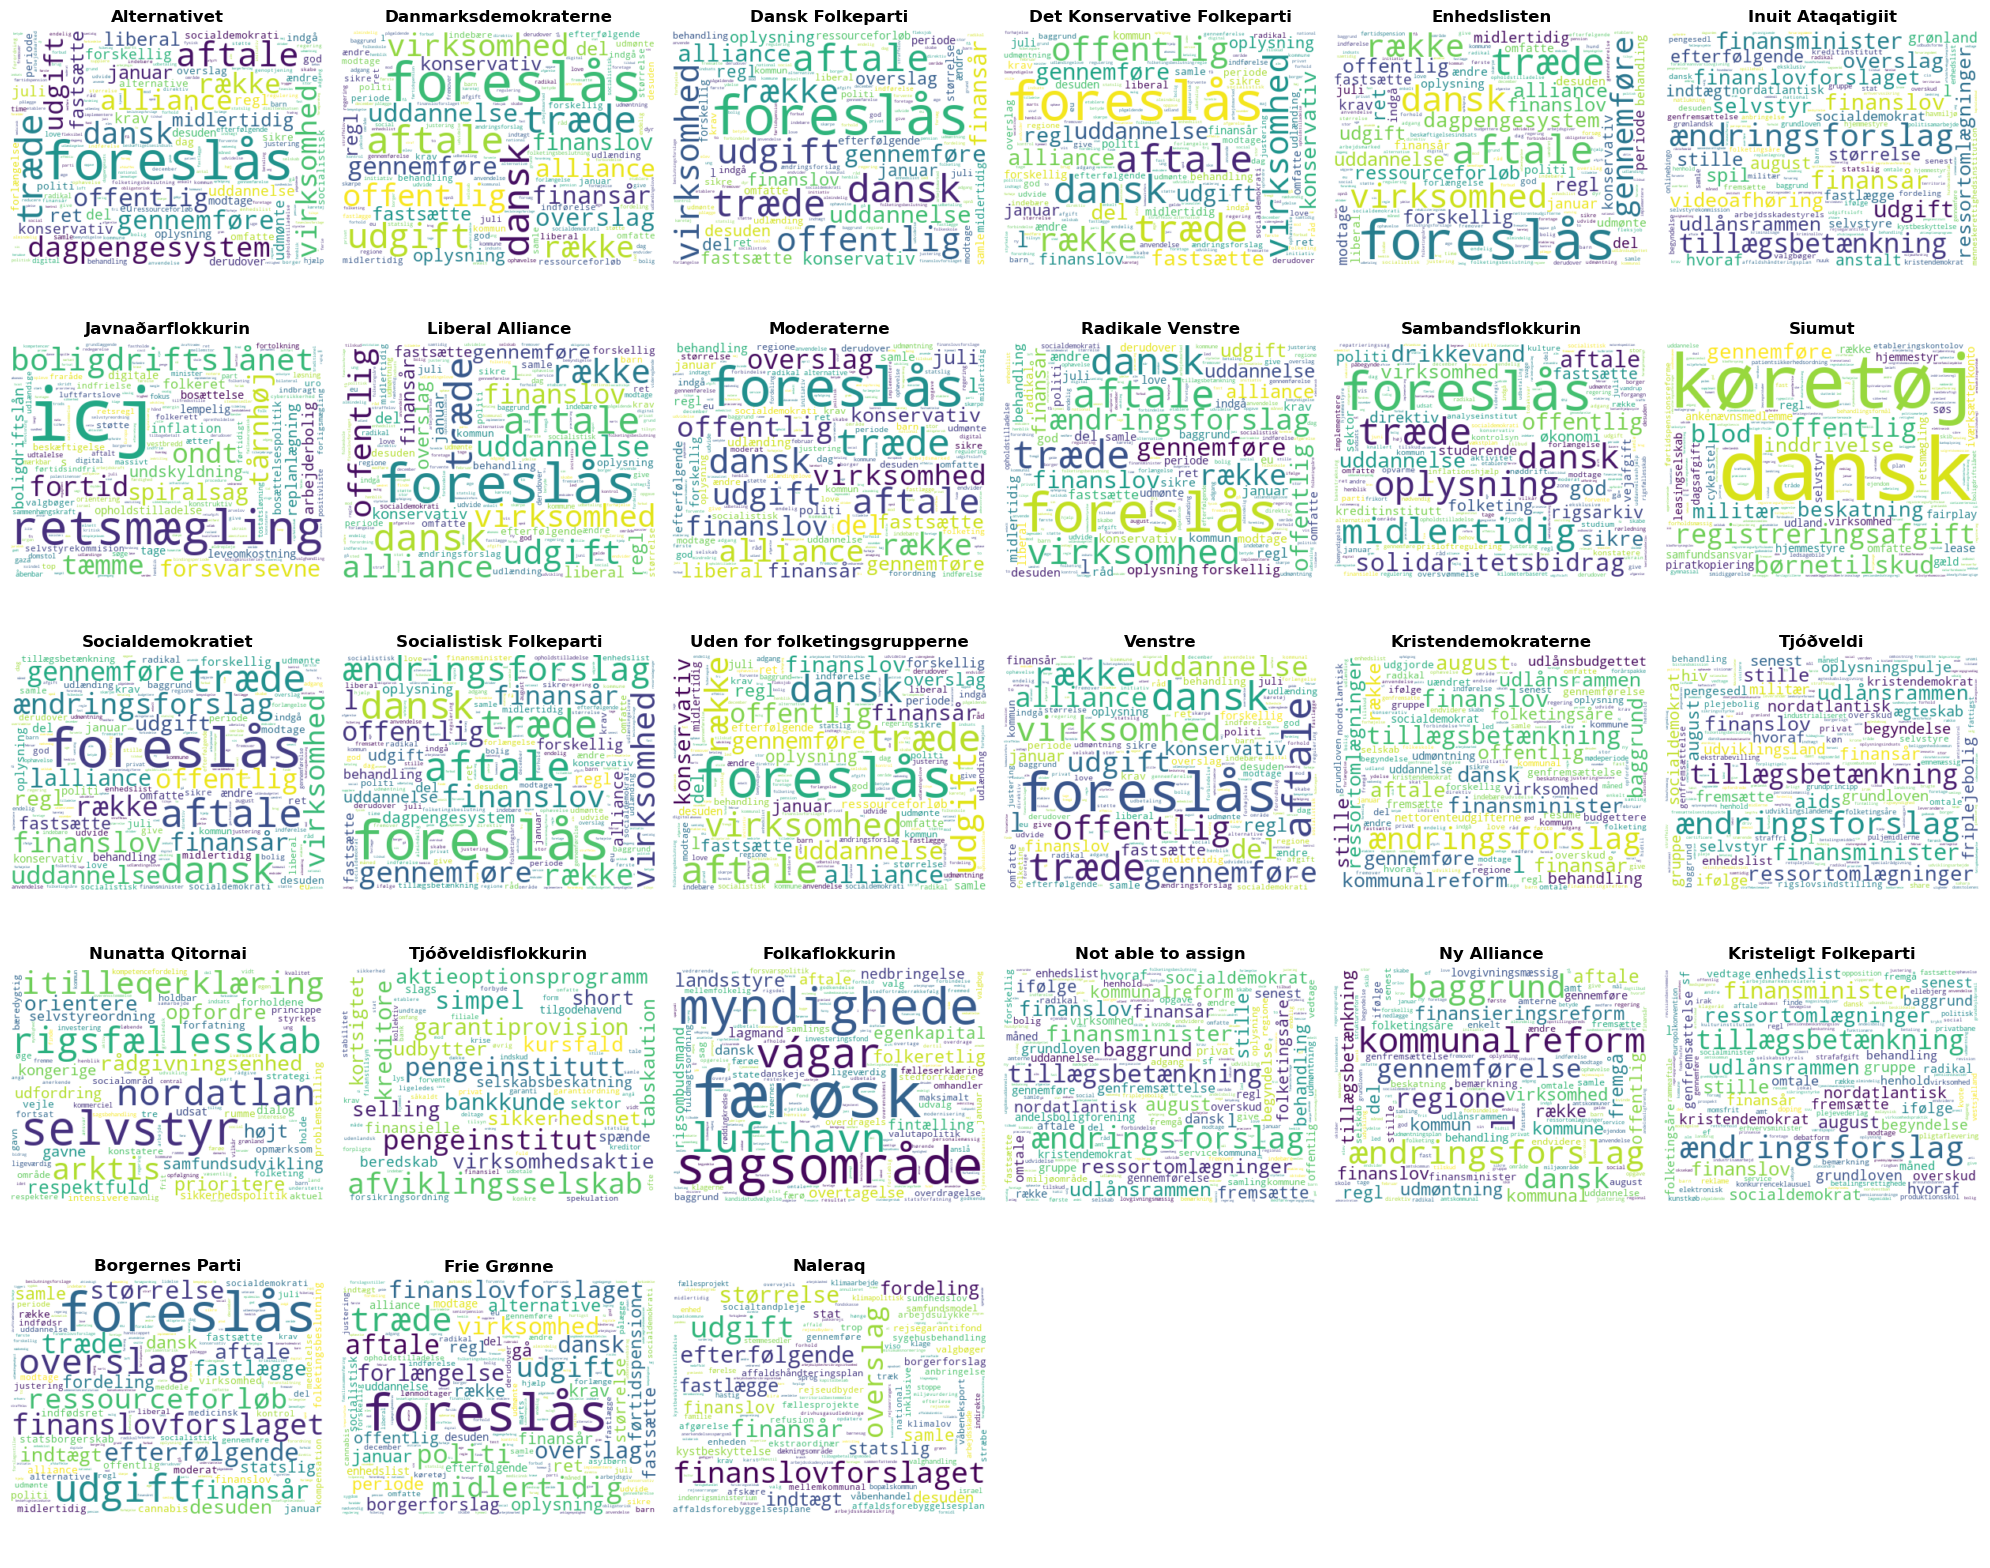

In [11]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

# Generate wordclouds for each party using TF-IDF scores
fig, axes = plt.subplots(5, 6, figsize=(20, 16))
axes = axes.flatten()

for idx, (party, tfidf_scores) in enumerate(party_tfidf.items()):
    if idx < len(axes):
        wordcloud = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(tfidf_scores)
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(party, fontsize=12, fontweight='bold')
        axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(party_tfidf), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Dispersion/Frequency Distributions


In [10]:
import pandas as pd
party_votes_df = pd.read_csv('voting-data/voting_session_party_percentages.csv')
voting_sessions_df = pd.read_csv('voting-data/voting_sessions_enriched.csv')

In [11]:
voting_sessions_df

,afstemning_id,afstemning_nummer,afstemning_konklusion,afstemning_vedtaget,afstemning_kommentar,afstemning_dato,afstemning_opdateringsdato,afstemning_typeid,møde_id,møde_dato,...,score_erhverv,score_finans_budget,score_arbejdsmarked_velfærd,score_immigration,score_forsvar_sikkerhed,score_udenrigs_eu,score_retspolitik,score_transport_infrastruktur,score_bolig,score_social_familie
0,1,411,"Vedtaget\n\n108 stemmer for forslaget (V, S, D...",True,NaN,NaN,2014-09-09T09:05:59.653,2,17,2014-09-09 09:00:00,...,0,0,0,0,0,0,0,0,0,0
1,2,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,NaN,2014-09-09T09:25:05.717,1,18,2014-09-09 09:15:00,...,2,2,0,0,1,1,0,0,0,0
2,3,1,"Vedtaget\n\n59 stemmer for forslaget (S, RV, S...",True,NaN,NaN,2018-01-24T16:46:33.99,3,41,2012-10-04 10:00:00,...,0,0,0,0,0,0,1,0,0,1
3,4,7,"Vedtaget\n\n72 stemmer for forslaget (S, DF, R...",True,NaN,NaN,2018-01-25T10:25:25.64,1,156,2012-11-06 00:00:00,...,0,1,2,0,0,0,0,0,0,0
4,5,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,NaN,2017-08-10T12:57:52.27,1,18,2014-09-09 09:15:00,...,2,2,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10301,10378,533,"Vedtaget\nFor stemte 93 (S, V, DD, SF, LA, M, ...",True,Grundet en teknisk fejl kunne der ikke stemmes...,NaN,2025-09-30T14:56:15.043,1,15399,2025-09-30 13:00:00,...,2,0,0,3,1,3,0,0,0,0
10302,10379,2,"Vedtaget\nFor stemte 59 (S, V, M, JF, Jeppe Sø...",True,NaN,NaN,2025-10-10T11:45:43.137,3,15443,2025-10-09 08:00:00,...,0,0,2,0,3,2,1,0,0,2
10303,10380,3,"Forslaget er vedtaget\nFor stemte 56 (S, V og ...",True,NaN,NaN,2025-10-24T09:45:23.93,3,15446,2025-10-23 10:00:00,...,0,0,0,0,0,0,0,0,0,0
10304,10381,5,"Forslaget er vedtaget.\nFor stemte 96 (S, V, D...",True,Ved en fejl stemte Alex Ahrendtsen (DF) for fo...,NaN,2025-11-24T11:14:43.697,1,15454,2025-11-20 10:15:00,...,2,1,0,0,0,1,0,0,0,0


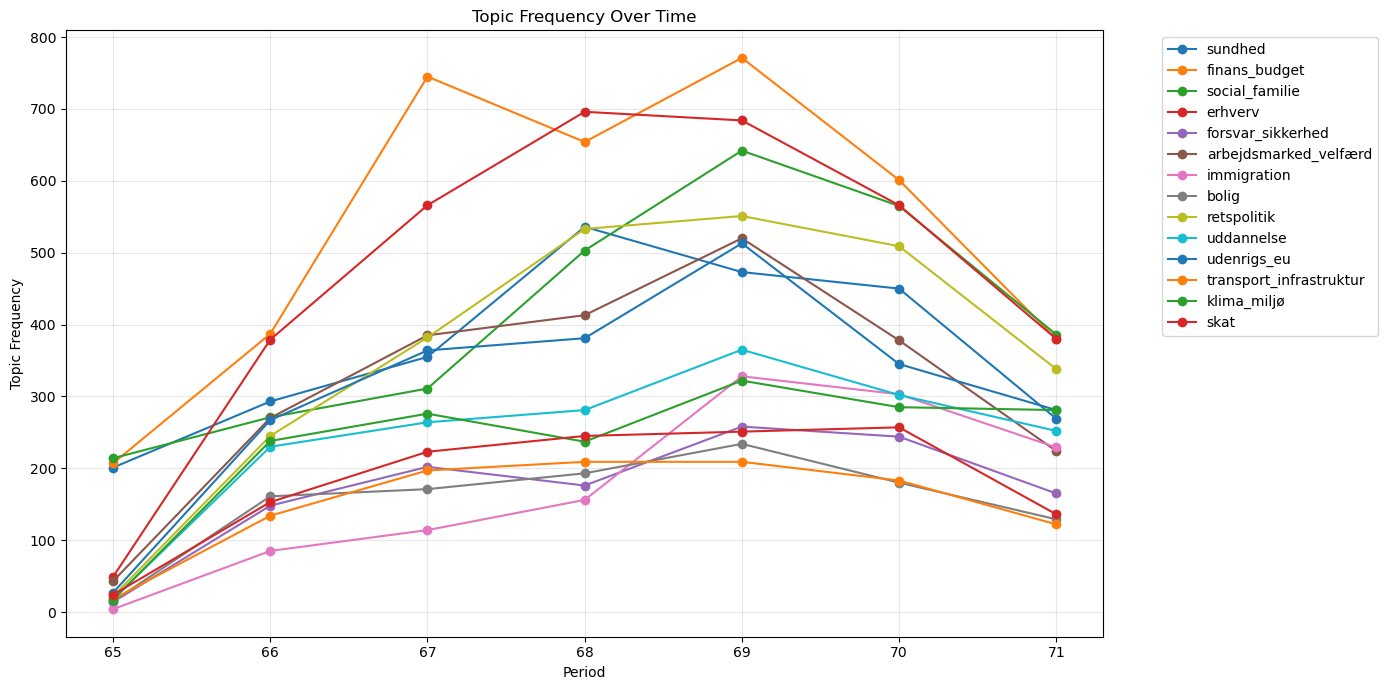

In [3]:
import ast
from collections import Counter

import matplotlib.pyplot as plt

# Parse all_topics and count occurrences by period
topic_counts_by_period = {}

for _, row in voting_sessions_df.iterrows():
    period = row['Period']
    topics_str = row['all_topics']
    
    # Parse the topics list
    try:
        topics = ast.literal_eval(topics_str) if isinstance(topics_str, str) else []
    except:
        topics = []
    
    if period not in topic_counts_by_period:
        topic_counts_by_period[period] = Counter()
    
    topic_counts_by_period[period].update(topics)

# Convert to dataframe for easier plotting
periods = sorted(topic_counts_by_period.keys())
all_topics_set = set()
for counter in topic_counts_by_period.values():
    all_topics_set.update(counter.keys())

# Create a dictionary for plotting
plot_data = {topic: [topic_counts_by_period[period].get(topic, 0) for period in periods] for topic in all_topics_set}

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
for topic, counts in plot_data.items():
    ax.plot(periods, counts, marker='o', label=topic)

ax.set_xlabel('Period')
ax.set_ylabel('Topic Frequency')
ax.set_title('Topic Frequency Over Time')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/7f/_d1gswbx4hngxw3tp2m2k9kr0000gn/T/ipykernel_18212/2342662156.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df_topics.groupby([pd.Grouper(key='date', freq='M'), 'topic']).size().unstack(fill_value=0)


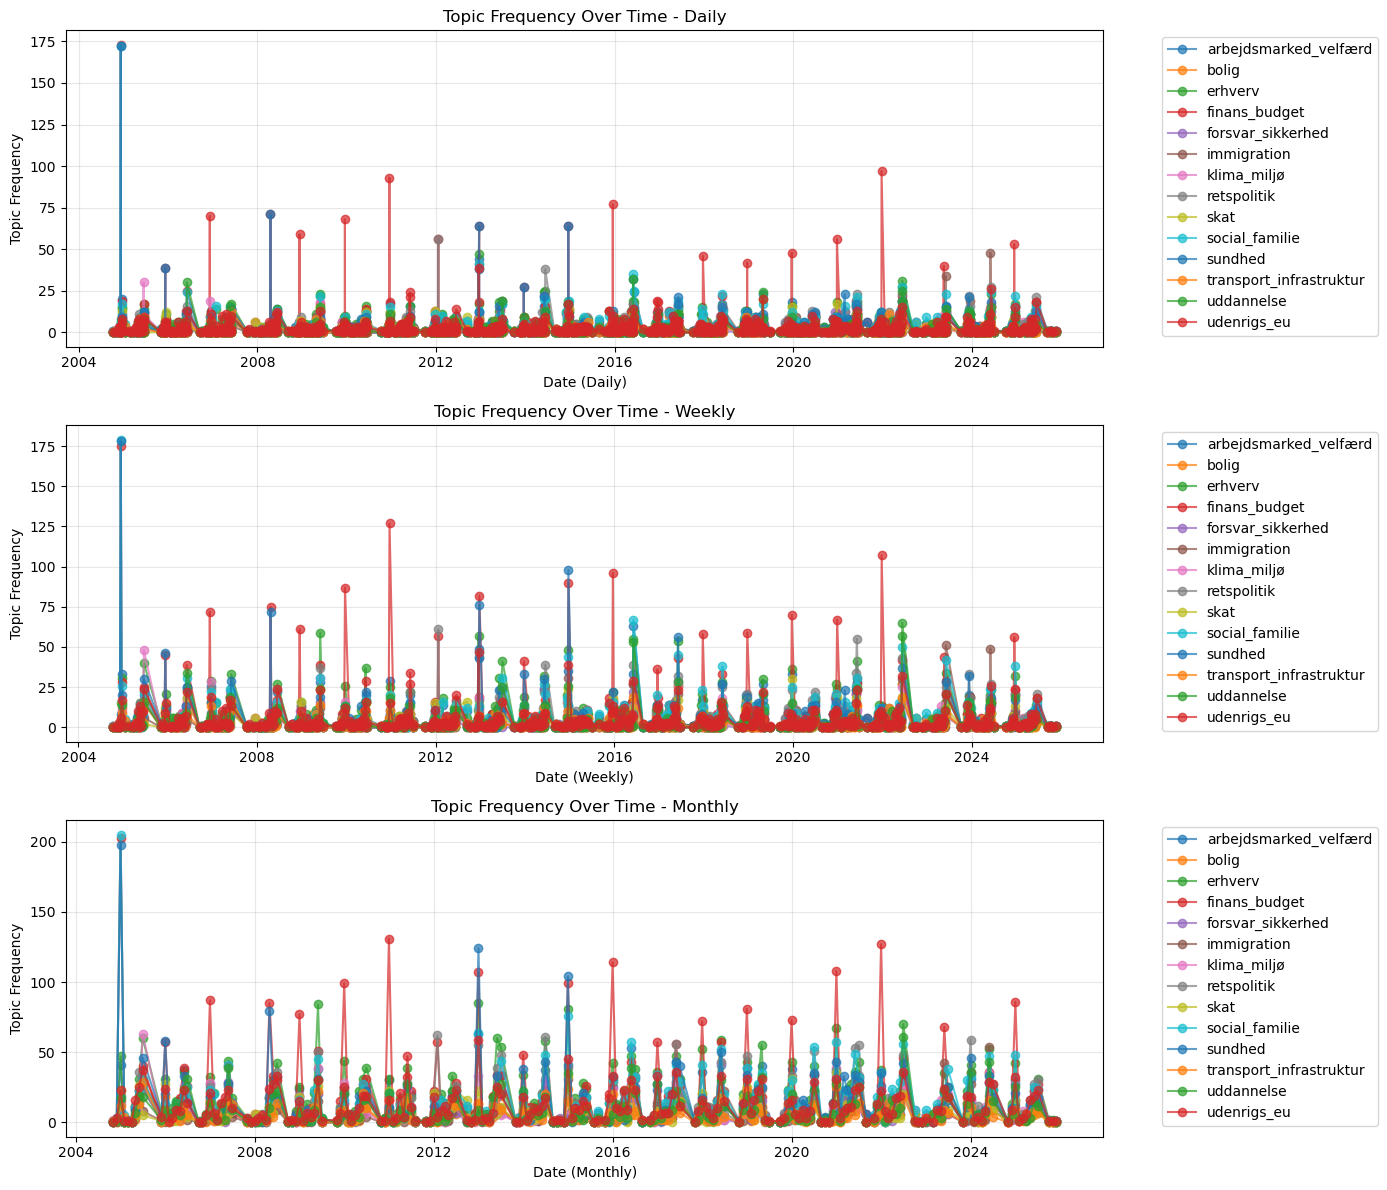

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Convert møde_dato to datetime
voting_sessions_df['møde_dato'] = pd.to_datetime(voting_sessions_df['møde_dato'])

# Parse all_topics and create a dataframe with dates
topic_data = []
for _, row in voting_sessions_df.iterrows():
    topics_str = row['all_topics']
    try:
        topics = ast.literal_eval(topics_str) if isinstance(topics_str, str) else []
    except:
        topics = []
    
    for topic in topics:
        topic_data.append({'date': row['møde_dato'], 'topic': topic})

df_topics = pd.DataFrame(topic_data)

# Create three separate aggregations
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Daily aggregation
daily_counts = df_topics.groupby([pd.Grouper(key='date', freq='D'), 'topic']).size().unstack(fill_value=0)
for topic in daily_counts.columns:
    axes[0].plot(daily_counts.index, daily_counts[topic], marker='o', label=topic, alpha=0.7)
axes[0].set_xlabel('Date (Daily)')
axes[0].set_ylabel('Topic Frequency')
axes[0].set_title('Topic Frequency Over Time - Daily')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Weekly aggregation
weekly_counts = df_topics.groupby([pd.Grouper(key='date', freq='W'), 'topic']).size().unstack(fill_value=0)
for topic in weekly_counts.columns:
    axes[1].plot(weekly_counts.index, weekly_counts[topic], marker='o', label=topic, alpha=0.7)
axes[1].set_xlabel('Date (Weekly)')
axes[1].set_ylabel('Topic Frequency')
axes[1].set_title('Topic Frequency Over Time - Weekly')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

# Monthly aggregation
monthly_counts = df_topics.groupby([pd.Grouper(key='date', freq='M'), 'topic']).size().unstack(fill_value=0)
for topic in monthly_counts.columns:
    axes[2].plot(monthly_counts.index, monthly_counts[topic], marker='o', label=topic, alpha=0.7)
axes[2].set_xlabel('Date (Monthly)')
axes[2].set_ylabel('Topic Frequency')
axes[2].set_title('Topic Frequency Over Time - Monthly')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/7f/_d1gswbx4hngxw3tp2m2k9kr0000gn/T/ipykernel_18212/988265678.py:48: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df_topics.groupby([pd.Grouper(key='date', freq='M'), 'topic']).size().unstack(fill_value=0)


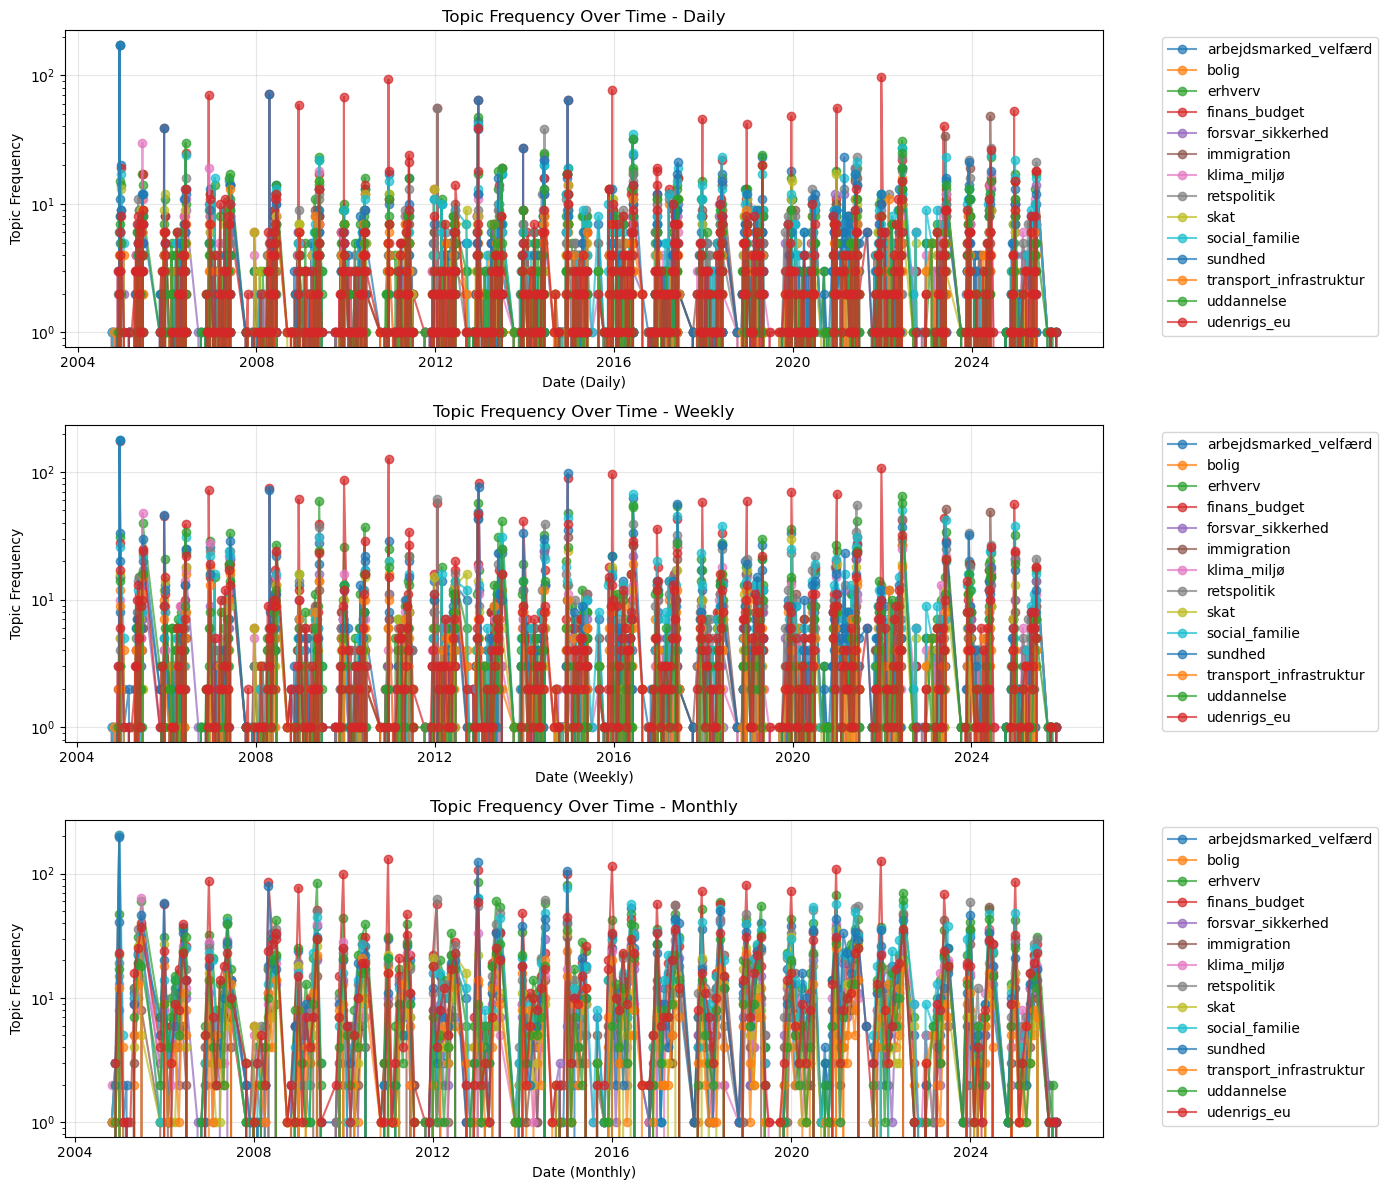

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Convert møde_dato to datetime
voting_sessions_df['møde_dato'] = pd.to_datetime(voting_sessions_df['møde_dato'])

# Parse all_topics and create a dataframe with dates
topic_data = []
for _, row in voting_sessions_df.iterrows():
    topics_str = row['all_topics']
    try:
        topics = ast.literal_eval(topics_str) if isinstance(topics_str, str) else []
    except:
        topics = []
    
    for topic in topics:
        topic_data.append({'date': row['møde_dato'], 'topic': topic})

df_topics = pd.DataFrame(topic_data)

# Create three separate aggregations
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Daily aggregation
daily_counts = df_topics.groupby([pd.Grouper(key='date', freq='D'), 'topic']).size().unstack(fill_value=0)
for topic in daily_counts.columns:
    axes[0].plot(daily_counts.index, daily_counts[topic], marker='o', label=topic, alpha=0.7)
axes[0].set_yscale('log')
axes[0].set_xlabel('Date (Daily)')
axes[0].set_ylabel('Topic Frequency')
axes[0].set_title('Topic Frequency Over Time - Daily')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Weekly aggregation
weekly_counts = df_topics.groupby([pd.Grouper(key='date', freq='W'), 'topic']).size().unstack(fill_value=0)
for topic in weekly_counts.columns:
    axes[1].plot(weekly_counts.index, weekly_counts[topic], marker='o', label=topic, alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_xlabel('Date (Weekly)')
axes[1].set_ylabel('Topic Frequency')
axes[1].set_title('Topic Frequency Over Time - Weekly')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

# Monthly aggregation
monthly_counts = df_topics.groupby([pd.Grouper(key='date', freq='M'), 'topic']).size().unstack(fill_value=0)
for topic in monthly_counts.columns:
    axes[2].plot(monthly_counts.index, monthly_counts[topic], marker='o', label=topic, alpha=0.7)
axes[2].set_yscale('log')
axes[2].set_xlabel('Date (Monthly)')
axes[2].set_ylabel('Topic Frequency')
axes[2].set_title('Topic Frequency Over Time - Monthly')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

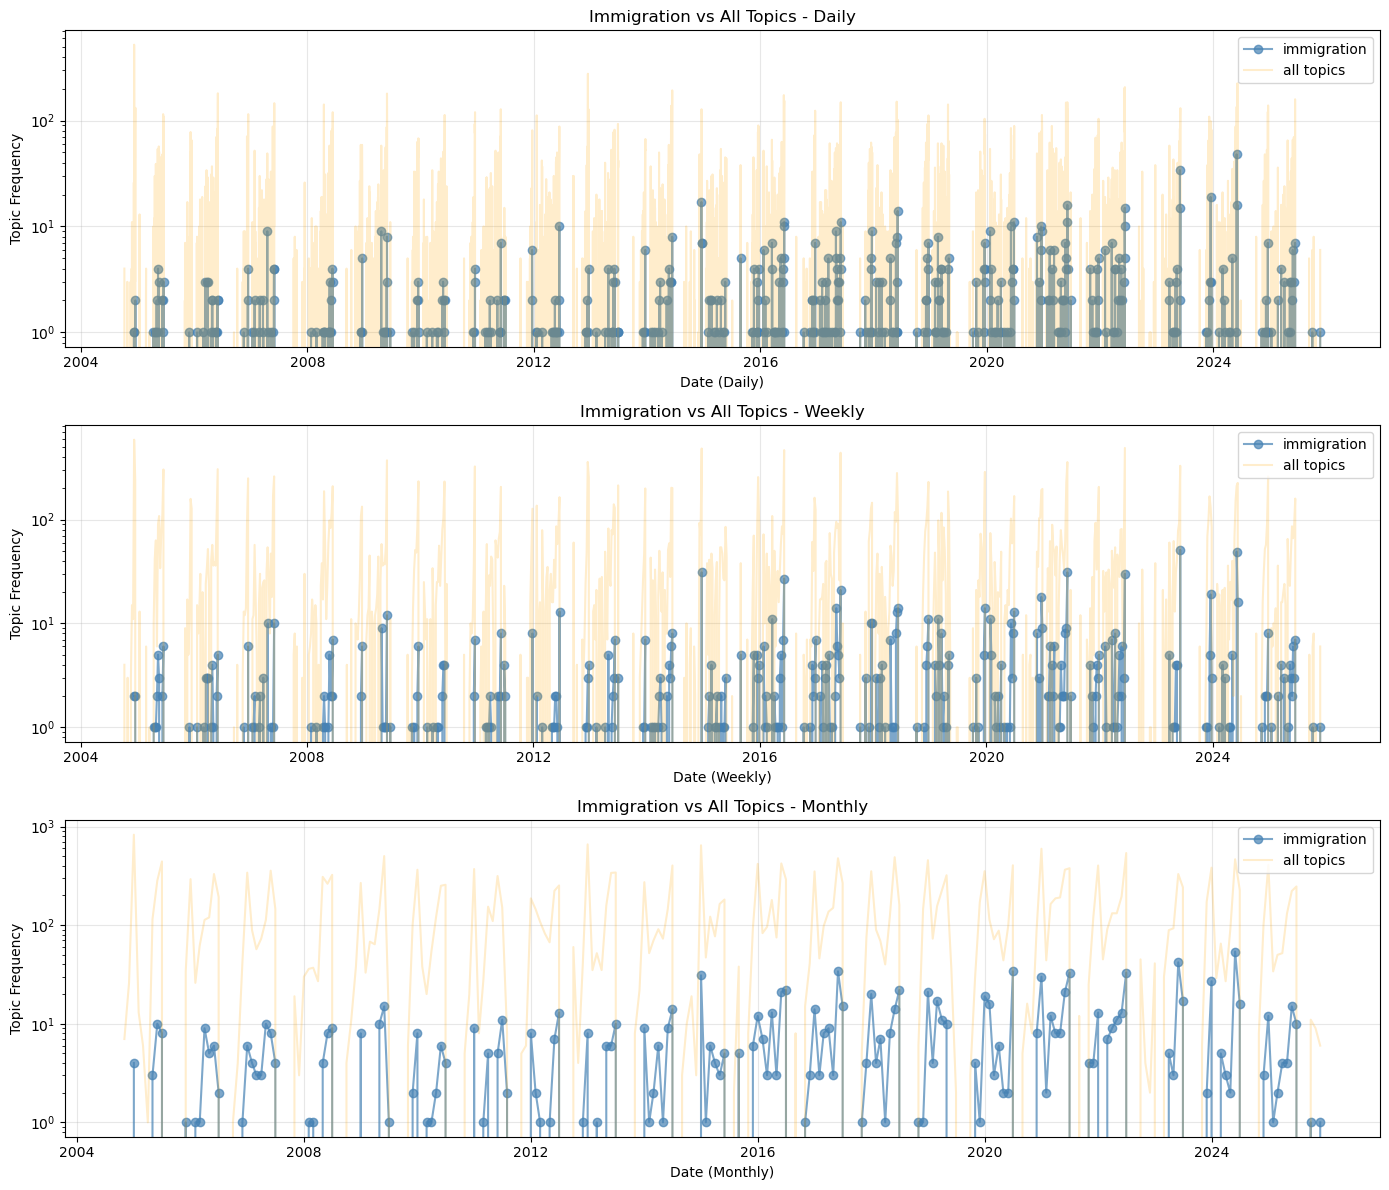

In [6]:
# Create topic-specific plots for immigration only
import matplotlib.pyplot as plt

# Filter topic_data for immigration only
immigration_data = [item for item in topic_data if item['topic'] == 'immigration']
df_immigration = pd.DataFrame(immigration_data)

# Create three separate aggregations
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Daily aggregation
daily_counts = df_immigration.groupby(pd.Grouper(key='date', freq='D')).size()
daily_all = df_topics.groupby(pd.Grouper(key='date', freq='D')).size()
axes[0].plot(daily_counts.index, daily_counts.values, marker='o', label='immigration', alpha=0.7, color='steelblue')
axes[0].plot(daily_all.index, daily_all.values, label='all topics', alpha=0.2, color='orange')
axes[0].set_yscale('log')
axes[0].set_xlabel('Date (Daily)')
axes[0].set_ylabel('Topic Frequency')
axes[0].set_title('Immigration vs All Topics - Daily')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Weekly aggregation
weekly_counts = df_immigration.groupby(pd.Grouper(key='date', freq='W')).size()
weekly_all = df_topics.groupby(pd.Grouper(key='date', freq='W')).size()
axes[1].plot(weekly_counts.index, weekly_counts.values, marker='o', label='immigration', alpha=0.7, color='steelblue')
axes[1].plot(weekly_all.index, weekly_all.values, label='all topics', alpha=0.2, color='orange')
axes[1].set_yscale('log')
axes[1].set_xlabel('Date (Weekly)')
axes[1].set_ylabel('Topic Frequency')
axes[1].set_title('Immigration vs All Topics - Weekly')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Monthly aggregation
monthly_counts = df_immigration.groupby(pd.Grouper(key='date', freq='ME')).size()
monthly_all = df_topics.groupby(pd.Grouper(key='date', freq='ME')).size()
axes[2].plot(monthly_counts.index, monthly_counts.values, marker='o', label='immigration', alpha=0.7, color='steelblue')
axes[2].plot(monthly_all.index, monthly_all.values, label='all topics', alpha=0.2, color='orange')
axes[2].set_yscale('log')
axes[2].set_xlabel('Date (Monthly)')
axes[2].set_ylabel('Topic Frequency')
axes[2].set_title('Immigration vs All Topics - Monthly')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

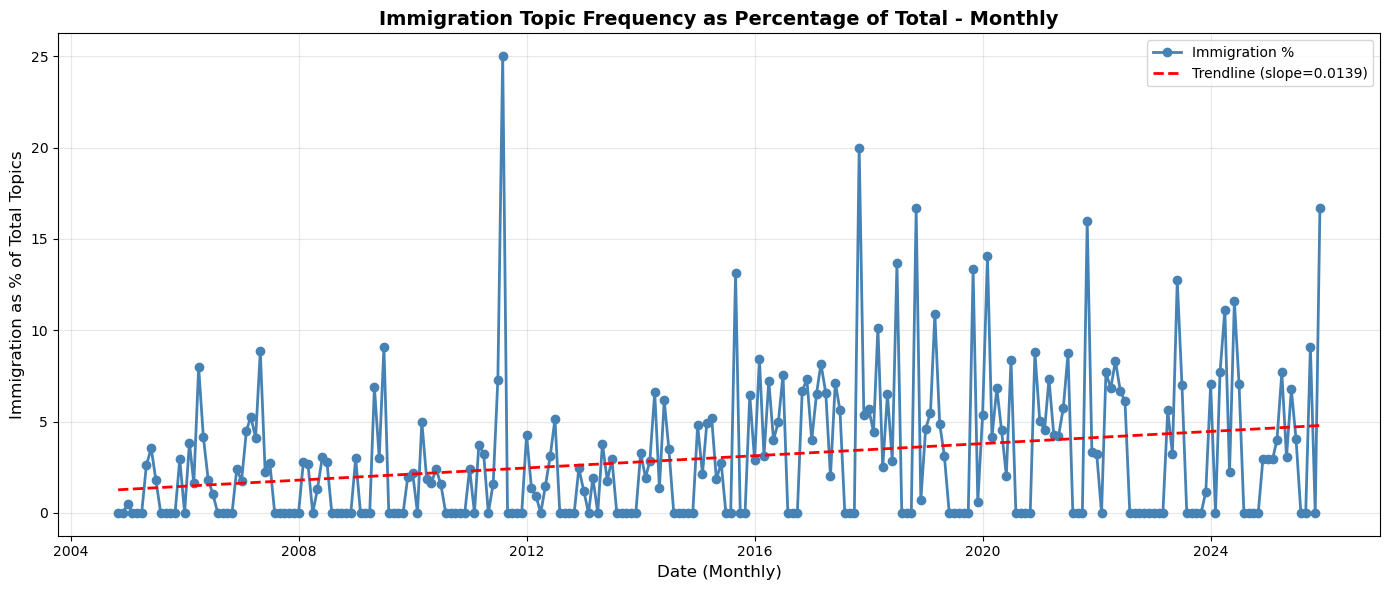

In [9]:
import numpy as np
from scipy import stats

# Calculate trendline using linear regression
x = np.arange(len(monthly_immigration_pct))
slope, intercept, r_value, p_value, std_err = stats.linregress(x, monthly_immigration_pct.values)
trendline = slope * x + intercept

# Create plot with trendline
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_immigration_pct.index, monthly_immigration_pct.values, marker='o', linewidth=2, markersize=6, color='steelblue', label='Immigration %')
ax.plot(monthly_immigration_pct.index, trendline, linewidth=2, color='red', linestyle='--', label=f'Trendline (slope={slope:.4f})')
ax.set_xlabel('Date (Monthly)', fontsize=12)
ax.set_ylabel('Immigration as % of Total Topics', fontsize=12)
ax.set_title('Immigration Topic Frequency as Percentage of Total - Monthly', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# Create a chronologically sorted corpus from topic_texts column
voting_sessions_df_sorted = voting_sessions_df.sort_values('møde_dato')

# Filter out NaN values and concatenate texts in chronological order
corpus = voting_sessions_df_sorted[voting_sessions_df_sorted['topic_texts'].notna()]['topic_texts'].tolist()

print(f"Corpus created with {len(corpus)} documents in chronological order")
print(f"Date range: {voting_sessions_df_sorted['møde_dato'].min()} to {voting_sessions_df_sorted['møde_dato'].max()}")

Corpus created with 10292 documents in chronological order
Date range: 2004-10-07 10:00:00 to 2025-11-20 10:15:00


In [16]:
from tqdm import tqdm
import spacy
nlp = spacy.load("da_core_news_sm")

# Lemmatize the corpus using spaCy
lemmatized_corpus = []

for doc_text in tqdm(corpus, desc="Lemmatizing corpus"):
    doc = nlp(doc_text.lower())
    lemmatized_tokens = [
        token.lemma_ for token in doc 
        if token.is_alpha 
        and not token.is_stop 
        #and token.lemma_ not in legislative_stopwords
    ]
    lemmatized_corpus.append(lemmatized_tokens)

print(f"Lemmatized corpus created with {len(lemmatized_corpus)} documents")
print(f"Sample document (first 20 tokens): {lemmatized_corpus[0][:20]}")

Lemmatizing corpus: 100%|██████████| 10292/10292 [02:32<00:00, 67.42it/s]

Lemmatized corpus created with 10292 documents
Sample document (first 20 tokens): ['idet', 'folketing', 'konstatere', 'aftale', 'vko', 'strukturreform', 'blive', 'bred', 'demokratisk', 'debat', 'forbindelse', 'valg', 'strukturreforme', 'engang', 'sin', 'faglig', 'grundlag', 'strukturkommission', 'betænkning', 'januar']


In [25]:
from nltk.text import Text
import nltk

# Flatten the lemmatized corpus into a single token list
flat_tokens = [token for doc in lemmatized_corpus for token in doc]

# Create NLTK Text object
text = Text(flat_tokens)

# Generate concordance for 'flygtninge'
text.concordance('invandrer')

no matches


In [27]:
# Find word offsets for 100k, 200k, etc. and their corresponding dates
offsets = [100000, 200000, 300000, 400000, 500000]
offset_dates = {}

cumulative_count = 0
current_doc_idx = 0

for offset in offsets:
    while cumulative_count < offset and current_doc_idx < len(lemmatized_corpus):
        cumulative_count += len(lemmatized_corpus[current_doc_idx])
        current_doc_idx += 1
    
    if current_doc_idx < len(voting_sessions_df_sorted):
        date = voting_sessions_df_sorted.iloc[current_doc_idx]['møde_dato']
        offset_dates[offset] = {'date': date, 'document_index': current_doc_idx}

print("Word Offset Milestones:")
print("=" * 60)
for offset, info in offset_dates.items():
    print(f"Offset {offset:>7d}: {info['date']} (Document #{info['document_index']})")

Word Offset Milestones:
Offset  100000: 2008-05-15 10:00:00 (Document #1773)
Offset  200000: 2012-05-22 13:00:00 (Document #3593)
Offset  300000: 2015-07-03 11:00:00 (Document #5068)
Offset  400000: 2018-05-24 10:00:00 (Document #6517)
Offset  500000: 2021-04-27 14:30:00 (Document #8013)


<Figure size 1400x600 with 0 Axes>

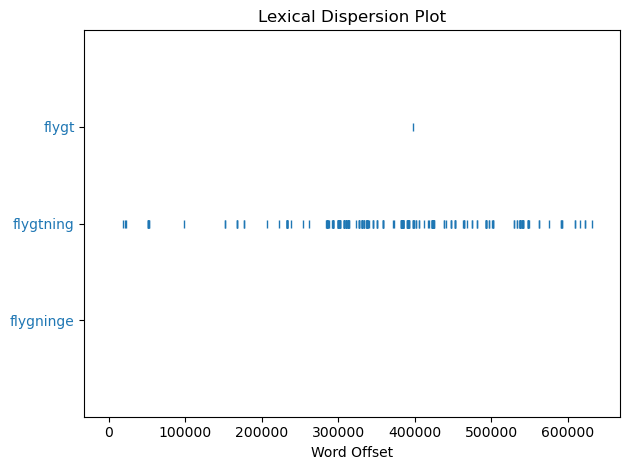

In [ ]:
from nltk.draw import dispersion_plot

import matplotlib.pyplot as plt

# Create dispersion plot for immigration-related terms
terms = ['flygt', 'flygtning', 'flygninge']
plt.figure(figsize=(14, 6))
dispersion_plot(text, terms)
plt.tight_layout()
plt.show()